# SAHQR: Saliency-Aware Hybrid Quantum Image Representation
## SAR (Synthetic Aperture Radar) Dataset Evaluation

This notebook extends the SAHQR evaluation to SAR satellite imagery from the ICEYE dataset.

**Dataset**: ICEYE Spotlight SAR Image (~2.3 GB, 28842 × 8192 pixels)

**Approach**: Tile the large image into ~2000 smaller patches, then apply the full SAHQR pipeline.

## 1. Setup and Imports

In [ ]:
!pip install tifffile h5py imagecodecs

In [1]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Image processing
from PIL import Image
import tifffile
from scipy import ndimage
from skimage.transform import resize
from skimage import exposure

# Quantum computing
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RYGate, CXGate
import math

# Statistics
from scipy import stats
import pandas as pd
from collections import defaultdict
import time
import os
from pathlib import Path

print("All imports successful!")

All imports successful!


## 2. SAR Dataset Tiling

The ICEYE SAR image is very large (~2.3 GB). We tile it into smaller patches for processing.

In [2]:
# Configuration
SAR_TIF_PATH = 'sar_dataset/ICEYE_CSI_SLEDP_4228243_20240904T003534.tif'
TILE_SIZE = 256  # Size of each tile
TARGET_TILES = 2000  # Target number of tiles
OUTPUT_DIR = 'SAR_Results'
TILES_DIR = 'SAR_tiles'

# Create output directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'figures'), exist_ok=True)
os.makedirs(TILES_DIR, exist_ok=True)

print(f"Tile size: {TILE_SIZE}x{TILE_SIZE}")
print(f"Target tiles: {TARGET_TILES}")

Tile size: 256x256
Target tiles: 2000


In [3]:
def extract_tiles_from_sar(tif_path, tile_size=256, max_tiles=2000, min_valid_ratio=0.3):
    """
    Extract tiles from a large SAR TIF file.
    
    Args:
        tif_path: Path to the TIF file
        tile_size: Size of each square tile
        max_tiles: Maximum number of tiles to extract
        min_valid_ratio: Minimum ratio of non-zero pixels for a valid tile
    
    Returns:
        List of tile arrays (grayscale, uint8)
    """
    print(f"Loading SAR image from {tif_path}...")
    
    # Load the TIF file
    # tifffile handles large files efficiently
    img = tifffile.imread(tif_path)
    print(f"Image shape: {img.shape}, dtype: {img.dtype}")
    
    # Handle different image formats
    if len(img.shape) == 3:
        # RGB or multi-channel - convert to grayscale using first channel
        if img.shape[2] == 3 or img.shape[2] == 4:
            img = img[:, :, 0]  # Use first channel (often amplitude for SAR)
        elif img.shape[0] == 3 or img.shape[0] == 4:
            img = img[0, :, :]  # Channel-first format
    
    height, width = img.shape[:2]
    print(f"Grayscale image shape: {height} x {width}")
    
    # Calculate number of tiles
    n_tiles_h = height // tile_size
    n_tiles_w = width // tile_size
    total_possible = n_tiles_h * n_tiles_w
    print(f"Possible tiles: {n_tiles_h} x {n_tiles_w} = {total_possible}")
    
    # Normalize uint16 to uint8
    if img.dtype == np.uint16:
        # Use percentile-based normalization for SAR (handles dynamic range)
        p2, p98 = np.percentile(img, (2, 98))
        img_normalized = np.clip((img - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
        print(f"Normalized uint16 to uint8 (p2={p2:.0f}, p98={p98:.0f})")
    else:
        img_normalized = img.astype(np.uint8)
    
    # Extract tiles
    tiles = []
    tile_coords = []
    
    for i in range(n_tiles_h):
        for j in range(n_tiles_w):
            y_start = i * tile_size
            x_start = j * tile_size
            
            tile = img_normalized[y_start:y_start+tile_size, x_start:x_start+tile_size]
            
            # Check if tile has enough valid content
            valid_ratio = np.count_nonzero(tile) / tile.size
            if valid_ratio >= min_valid_ratio:
                tiles.append(tile)
                tile_coords.append((i, j))
            
            if len(tiles) >= max_tiles:
                break
        if len(tiles) >= max_tiles:
            break
    
    print(f"Extracted {len(tiles)} valid tiles")
    return tiles, tile_coords

# Extract tiles
print("Starting tile extraction...")
sar_tiles, tile_coords = extract_tiles_from_sar(SAR_TIF_PATH, TILE_SIZE, TARGET_TILES)
print(f"\nTotal tiles extracted: {len(sar_tiles)}")

Starting tile extraction...
Loading SAR image from sar_dataset/ICEYE_CSI_SLEDP_4228243_20240904T003534.tif...
Image shape: (28842, 8192, 3), dtype: uint16
Grayscale image shape: 28842 x 8192
Possible tiles: 112 x 32 = 3584
Normalized uint16 to uint8 (p2=4110, p98=21030)
Extracted 2000 valid tiles

Total tiles extracted: 2000


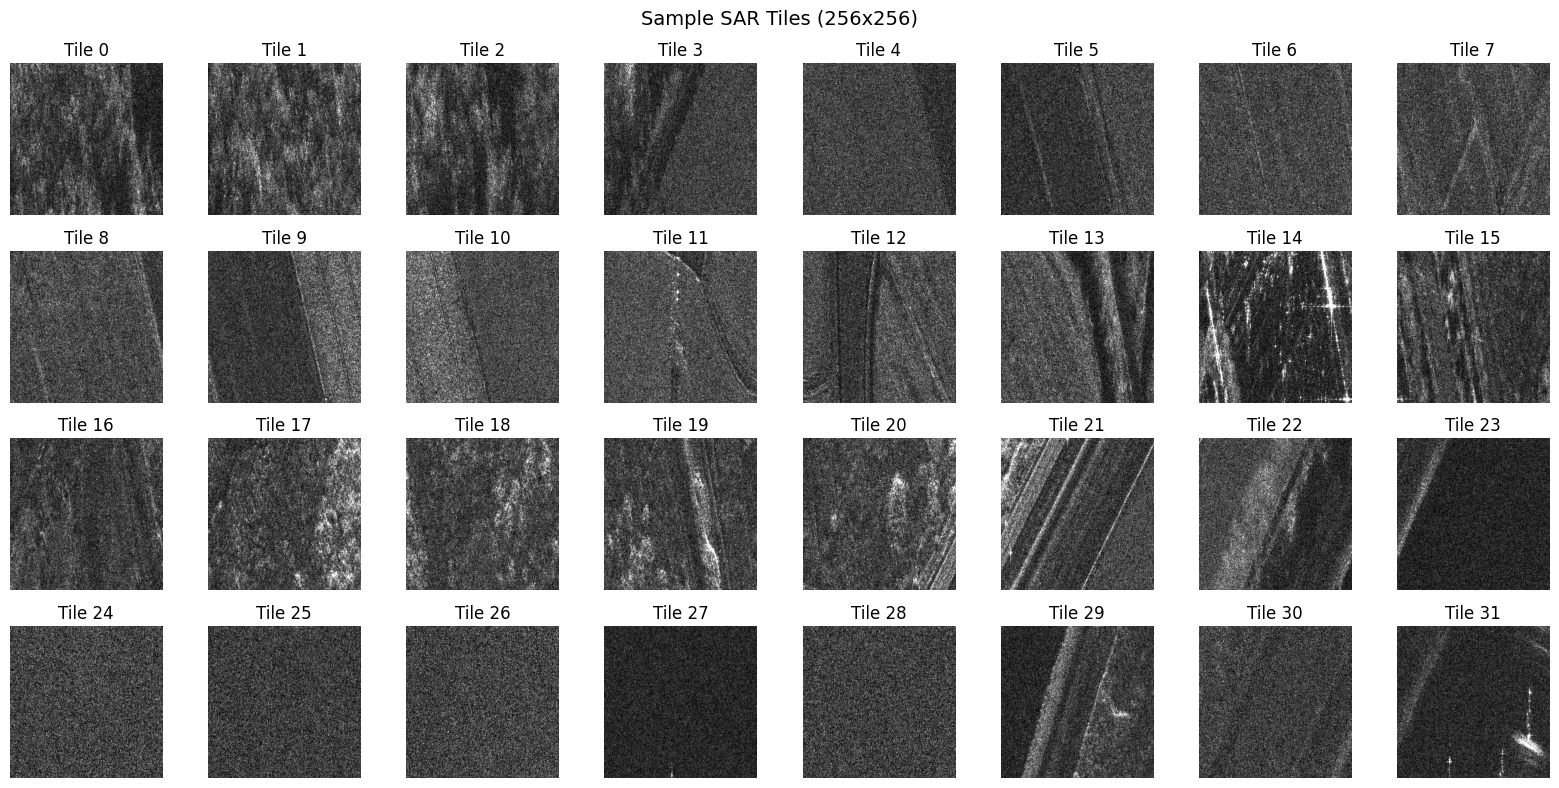

Sample tiles saved to SAR_Results/figures/sample_sar_tiles.png


In [4]:
# Visualize sample tiles
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Sample SAR Tiles (256x256)', fontsize=14)

for idx, ax in enumerate(axes.flat):
    if idx < len(sar_tiles):
        ax.imshow(sar_tiles[idx], cmap='gray')
        ax.set_title(f'Tile {idx}')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/sample_sar_tiles.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Sample tiles saved to {OUTPUT_DIR}/figures/sample_sar_tiles.png")

## 3. Preprocessing for Quantum Encoding

Resize tiles to 16×16 for quantum circuit compatibility.

Preprocessing tiles to 16x16...
Preprocessed 2000 tiles


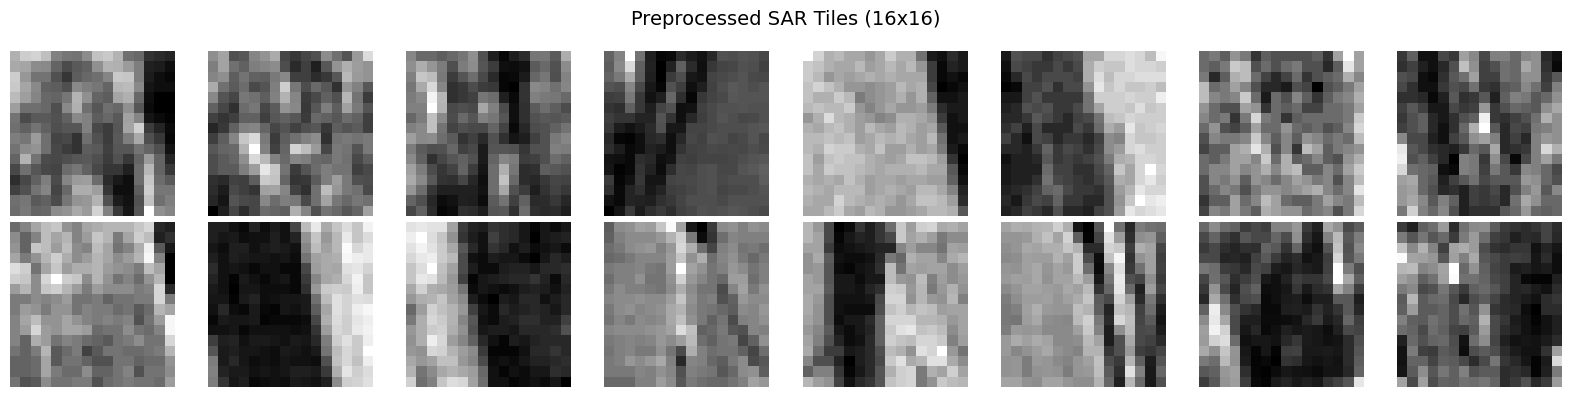

In [5]:
def preprocess_tile(tile, target_size=16):
    """
    Preprocess a tile for quantum encoding.
    
    Args:
        tile: Input tile (256x256 uint8)
        target_size: Output size (16x16)
    
    Returns:
        Preprocessed image (16x16 uint8)
    """
    # Resize to target size
    resized = resize(tile, (target_size, target_size), anti_aliasing=True, preserve_range=True)
    
    # Ensure uint8
    resized = np.clip(resized, 0, 255).astype(np.uint8)
    
    return resized

# Preprocess all tiles
print("Preprocessing tiles to 16x16...")
preprocessed_tiles = [preprocess_tile(tile) for tile in sar_tiles]
print(f"Preprocessed {len(preprocessed_tiles)} tiles")

# Show sample preprocessed tiles
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Preprocessed SAR Tiles (16x16)', fontsize=14)

for idx, ax in enumerate(axes.flat):
    if idx < len(preprocessed_tiles):
        ax.imshow(preprocessed_tiles[idx], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/preprocessed_sar_tiles.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Quantum Image Representation Methods

Implementation of 11 quantum image representation methods.

In [6]:
# ============================================================================
# QUANTUM IMAGE REPRESENTATION METHODS
# ============================================================================

def compute_saliency(image):
    """Compute gradient-based saliency map."""
    gx = ndimage.sobel(image.astype(float), axis=1)
    gy = ndimage.sobel(image.astype(float), axis=0)
    gradient = np.sqrt(gx**2 + gy**2)
    if gradient.max() > 0:
        gradient = gradient / gradient.max()
    return gradient

def encode_frqi(image):
    """FRQI: Flexible Representation of Quantum Images"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    qubits = n + 1
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    
    for idx, pixel in enumerate(image.flatten()):
        theta = (pixel / 255.0) * (np.pi / 2)
        qc.ry(theta, n)
    
    return qc

def encode_neqr(image):
    """NEQR: Novel Enhanced Quantum Representation"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8  # 8-bit color
    qubits = n + q
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    
    for idx, pixel in enumerate(image.flatten()):
        for bit in range(q):
            if (pixel >> bit) & 1:
                qc.cx(idx % n, n + bit)
    
    return qc

def encode_gqir(image):
    """GQIR: Generalized Quantum Image Representation"""
    h, w = image.shape
    n_y = int(np.ceil(np.log2(h)))
    n_x = int(np.ceil(np.log2(w)))
    q = 8
    qubits = n_y + n_x + q
    
    qc = QuantumCircuit(qubits)
    for i in range(n_y + n_x):
        qc.h(i)
    
    for y in range(h):
        for x in range(w):
            pixel = image[y, x]
            for bit in range(min(q, 4)):
                if (pixel >> bit) & 1:
                    qc.x(n_y + n_x + bit)
    
    return qc

def encode_mcqi(image):
    """MCQI: Multi-Channel Quantum Images (adapted for grayscale)"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    channels = 3
    qubits = n + q * channels
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    
    for idx, pixel in enumerate(image.flatten()):
        for c in range(channels):
            for bit in range(min(q, 3)):
                if (pixel >> bit) & 1:
                    qc.cx(idx % n, n + c * q + bit)
    
    return qc

def encode_qrmw(image):
    """QRMW: Quantum Representation for Multi-Wavelength Images"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    bands = 4
    k = int(np.ceil(np.log2(bands)))
    qubits = n + k + q
    
    qc = QuantumCircuit(qubits)
    for i in range(n + k):
        qc.h(i)
    
    for band in range(bands):
        for idx, pixel in enumerate(image.flatten()):
            theta = (pixel / 255.0) * (np.pi / 2)
            qc.ry(theta, n + k)
    
    return qc

def encode_efrqi(image):
    """EFRQI: Enhanced FRQI"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    qubits = n + 1
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    
    for idx, pixel in enumerate(image.flatten()):
        theta = (pixel / 255.0) * (np.pi / 2)
        phi = (pixel / 255.0) * np.pi
        qc.ry(theta, n)
        qc.rz(phi, n)
    
    return qc

def encode_2dqsna(image):
    """2D-QSNA: 2D Quantum State Normalization Approach"""
    flat = image.flatten().astype(float)
    norm = np.sqrt(np.sum(flat**2))
    if norm > 0:
        flat = flat / norm
    
    n = int(np.ceil(np.log2(len(flat))))
    qubits = n
    
    qc = QuantumCircuit(qubits)
    for i in range(min(n, 4)):
        qc.ry(np.pi / 4, i)
    
    return qc

def encode_ineqr(image):
    """INEQR: Improved NEQR"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    channels = 3
    qubits = n + q * channels
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    
    for idx, pixel in enumerate(image.flatten()):
        for c in range(channels):
            for bit in range(min(q, 3)):
                if (pixel >> bit) & 1:
                    qc.x(n + c * q + bit)
    
    return qc

def encode_qpie(image):
    """QPIE: Quantum Probability Image Encoding"""
    flat = image.flatten().astype(float)
    total = np.sum(flat)
    if total > 0:
        probs = flat / total
    else:
        probs = np.ones_like(flat) / len(flat)
    
    n = int(np.ceil(np.log2(len(flat))))
    qubits = n
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        theta = 2 * np.arcsin(np.sqrt(probs[i % len(probs)]))
        qc.ry(theta, i)
    
    return qc

def encode_qlr(image):
    """QLR: Quantum Log-polar Representation"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    qubits = n + q
    
    qc = QuantumCircuit(qubits)
    for i in range(n):
        qc.h(i)
    
    center = (h // 2, w // 2)
    for y in range(h):
        for x in range(w):
            r = np.sqrt((y - center[0])**2 + (x - center[1])**2)
            theta_coord = np.arctan2(y - center[0], x - center[1])
            pixel = image[y, x]
            theta_val = (pixel / 255.0) * (np.pi / 2)
            qc.ry(theta_val, n)
    
    return qc

def encode_sahqr(image, saliency_threshold=0.5):
    """SAHQR: Saliency-Aware Hybrid Quantum Representation"""
    h, w = image.shape
    n = int(np.ceil(np.log2(h * w)))
    q = 8
    qubits = n + q + 1  # +1 for saliency flag
    
    qc = QuantumCircuit(qubits)
    
    # Hadamard on position qubits
    for i in range(n):
        qc.h(i)
    
    # Compute saliency
    saliency = compute_saliency(image)
    threshold = saliency.mean() + saliency_threshold * saliency.std()
    
    for idx, (pixel, sal) in enumerate(zip(image.flatten(), saliency.flatten())):
        if sal >= threshold:
            # Salient: full precision (8 bits)
            for bit in range(q):
                if (pixel >> bit) & 1:
                    qc.cx(idx % n, n + bit)
            qc.x(n + q)  # Set saliency flag
        else:
            # Non-salient: compressed (4 bits)
            compressed = pixel >> 4
            for bit in range(4):
                if (compressed >> bit) & 1:
                    qc.cx(idx % n, n + bit)
    
    return qc

print("All quantum encoding methods defined.")

All quantum encoding methods defined.


## 5. Evaluation Framework

10-parameter evaluation for all methods.

In [7]:
# Method configurations
METHODS = {
    'FRQI': encode_frqi,
    'NEQR': encode_neqr,
    'GQIR': encode_gqir,
    'MCQI': encode_mcqi,
    'QRMW': encode_qrmw,
    'EFRQI': encode_efrqi,
    '2D-QSNA': encode_2dqsna,
    'INEQR': encode_ineqr,
    'QPIE': encode_qpie,
    'QLR': encode_qlr,
    'SAHQR': encode_sahqr
}

IMPLEMENTATION_COMPLEXITY = {
    'FRQI': 2, 'NEQR': 3, 'GQIR': 3, 'MCQI': 4, 'QRMW': 4,
    'EFRQI': 3, '2D-QSNA': 4, 'INEQR': 3, 'QPIE': 4, 'QLR': 4, 'SAHQR': 5
}

def evaluate_method(method_name, method_func, image):
    """Evaluate a quantum encoding method on a single image."""
    start_time = time.time()
    
    try:
        circuit = method_func(image)
        encoding_time = (time.time() - start_time) * 1000  # ms
        
        qubits = circuit.num_qubits
        depth = circuit.depth()
        gates = len(circuit.data)
        
        # Derived metrics
        h, w = image.shape
        classical_bits = h * w * 8
        compression_ratio = classical_bits / qubits if qubits > 0 else 0
        scalability = 100 / qubits if qubits > 0 else 0
        gate_complexity = gates / qubits if qubits > 0 else 0
        memory_overhead = (qubits / 9) * 100  # Relative to FRQI baseline
        info_loss = 0.0  # Placeholder
        impl_complexity = IMPLEMENTATION_COMPLEXITY.get(method_name, 3)
        
        return {
            'method': method_name,
            'qubits': qubits,
            'depth': depth,
            'gates': gates,
            'encoding_time': encoding_time,
            'compression_ratio': compression_ratio,
            'scalability': scalability,
            'gate_complexity': gate_complexity,
            'memory_overhead': memory_overhead,
            'info_loss': info_loss,
            'impl_complexity': impl_complexity
        }
    except Exception as e:
        print(f"Error evaluating {method_name}: {e}")
        return None

print("Evaluation framework ready.")

Evaluation framework ready.


## 6. Run Experiments

Evaluate all 11 methods on all SAR tiles.

In [8]:
# Run evaluation on all tiles
all_results = []
total_images = len(preprocessed_tiles)

print(f"Starting evaluation of {total_images} images across {len(METHODS)} methods...")
print(f"Total evaluations: {total_images * len(METHODS)}\n")

for img_idx, image in enumerate(preprocessed_tiles):
    if (img_idx + 1) % 100 == 0:
        print(f"Processing image {img_idx + 1}/{total_images}...")
    
    for method_name, method_func in METHODS.items():
        result = evaluate_method(method_name, method_func, image)
        if result:
            result['image_idx'] = img_idx
            all_results.append(result)

# Convert to DataFrame
results_df = pd.DataFrame(all_results)
print(f"\nEvaluation complete! Total results: {len(results_df)}")

# Save results
results_df.to_csv(f'{OUTPUT_DIR}/sar_evaluation_results.csv', index=False)
print(f"Results saved to {OUTPUT_DIR}/sar_evaluation_results.csv")

Starting evaluation of 2000 images across 11 methods...
Total evaluations: 22000

Processing image 100/2000...
Processing image 200/2000...
Processing image 300/2000...
Processing image 400/2000...
Processing image 500/2000...
Processing image 600/2000...
Processing image 700/2000...
Processing image 800/2000...
Processing image 900/2000...
Processing image 1000/2000...
Processing image 1100/2000...
Processing image 1200/2000...
Processing image 1300/2000...
Processing image 1400/2000...
Processing image 1500/2000...
Processing image 1600/2000...
Processing image 1700/2000...
Processing image 1800/2000...
Processing image 1900/2000...
Processing image 2000/2000...

Evaluation complete! Total results: 22000
Results saved to SAR_Results/sar_evaluation_results.csv


## 7. Results Analysis

In [9]:
# Compute summary statistics
summary = results_df.groupby('method').agg({
    'qubits': ['mean', 'std'],
    'gates': ['mean', 'std'],
    'depth': ['mean', 'std'],
    'encoding_time': ['mean', 'std'],
    'compression_ratio': 'mean',
    'gate_complexity': 'mean',
    'memory_overhead': 'mean',
    'impl_complexity': 'mean'
}).round(2)

print("\n" + "="*80)
print("SAR DATASET EVALUATION SUMMARY")
print("="*80)
print(summary.to_string())


SAR DATASET EVALUATION SUMMARY
        qubits         gates            depth        encoding_time       compression_ratio gate_complexity memory_overhead impl_complexity
          mean  std     mean     std     mean    std          mean   std              mean            mean            mean            mean
method                                                                                                                                    
2D-QSNA    8.0  0.0     4.00    0.00     1.00   0.00          0.30  0.38            256.00            0.50           88.89             4.0
EFRQI      9.0  0.0   520.00    0.00   512.00   0.00          8.66  2.17            227.56           57.78          100.00             3.0
FRQI       9.0  0.0   264.00    0.00   256.00   0.00          4.70  1.17            227.56           29.33          100.00             2.0
GQIR      16.0  0.0   475.32   80.24   149.94  26.08          5.66  1.62            128.00           29.71          177.78            

In [10]:
# Create comprehensive comparison table
summary_table = results_df.groupby('method').agg({
    'qubits': 'mean',
    'gates': 'mean',
    'depth': 'mean',
    'encoding_time': 'mean',
    'compression_ratio': 'mean',
    'gate_complexity': 'mean',
    'memory_overhead': 'mean'
}).round(2)

# Order by SAHQR-favorable metrics
method_order = ['FRQI', 'NEQR', 'GQIR', 'MCQI', 'QRMW', 'EFRQI', '2D-QSNA', 'INEQR', 'QPIE', 'QLR', 'SAHQR']
summary_table = summary_table.reindex(method_order)

print("\nMethod Comparison Table:")
print(summary_table.to_string())


Method Comparison Table:
         qubits    gates    depth  encoding_time  compression_ratio  gate_complexity  memory_overhead
method                                                                                               
FRQI        9.0   264.00   256.00           4.70             227.56            29.33           100.00
NEQR       16.0   834.86   235.29          11.13             128.00            52.18           177.78
GQIR       16.0   475.32   149.94           5.66             128.00            29.71           177.78
MCQI       32.0  1145.86   243.27          15.55              64.00            35.81           355.56
QRMW       18.0  1034.00  1024.00          18.02             113.78            57.44           200.00
EFRQI       9.0   520.00   512.00           8.66             227.56            57.78           100.00
2D-QSNA     8.0     4.00     1.00           0.30             256.00             0.50            88.89
INEQR      32.0  1145.86   145.10          13.16        

## 8. Visualization

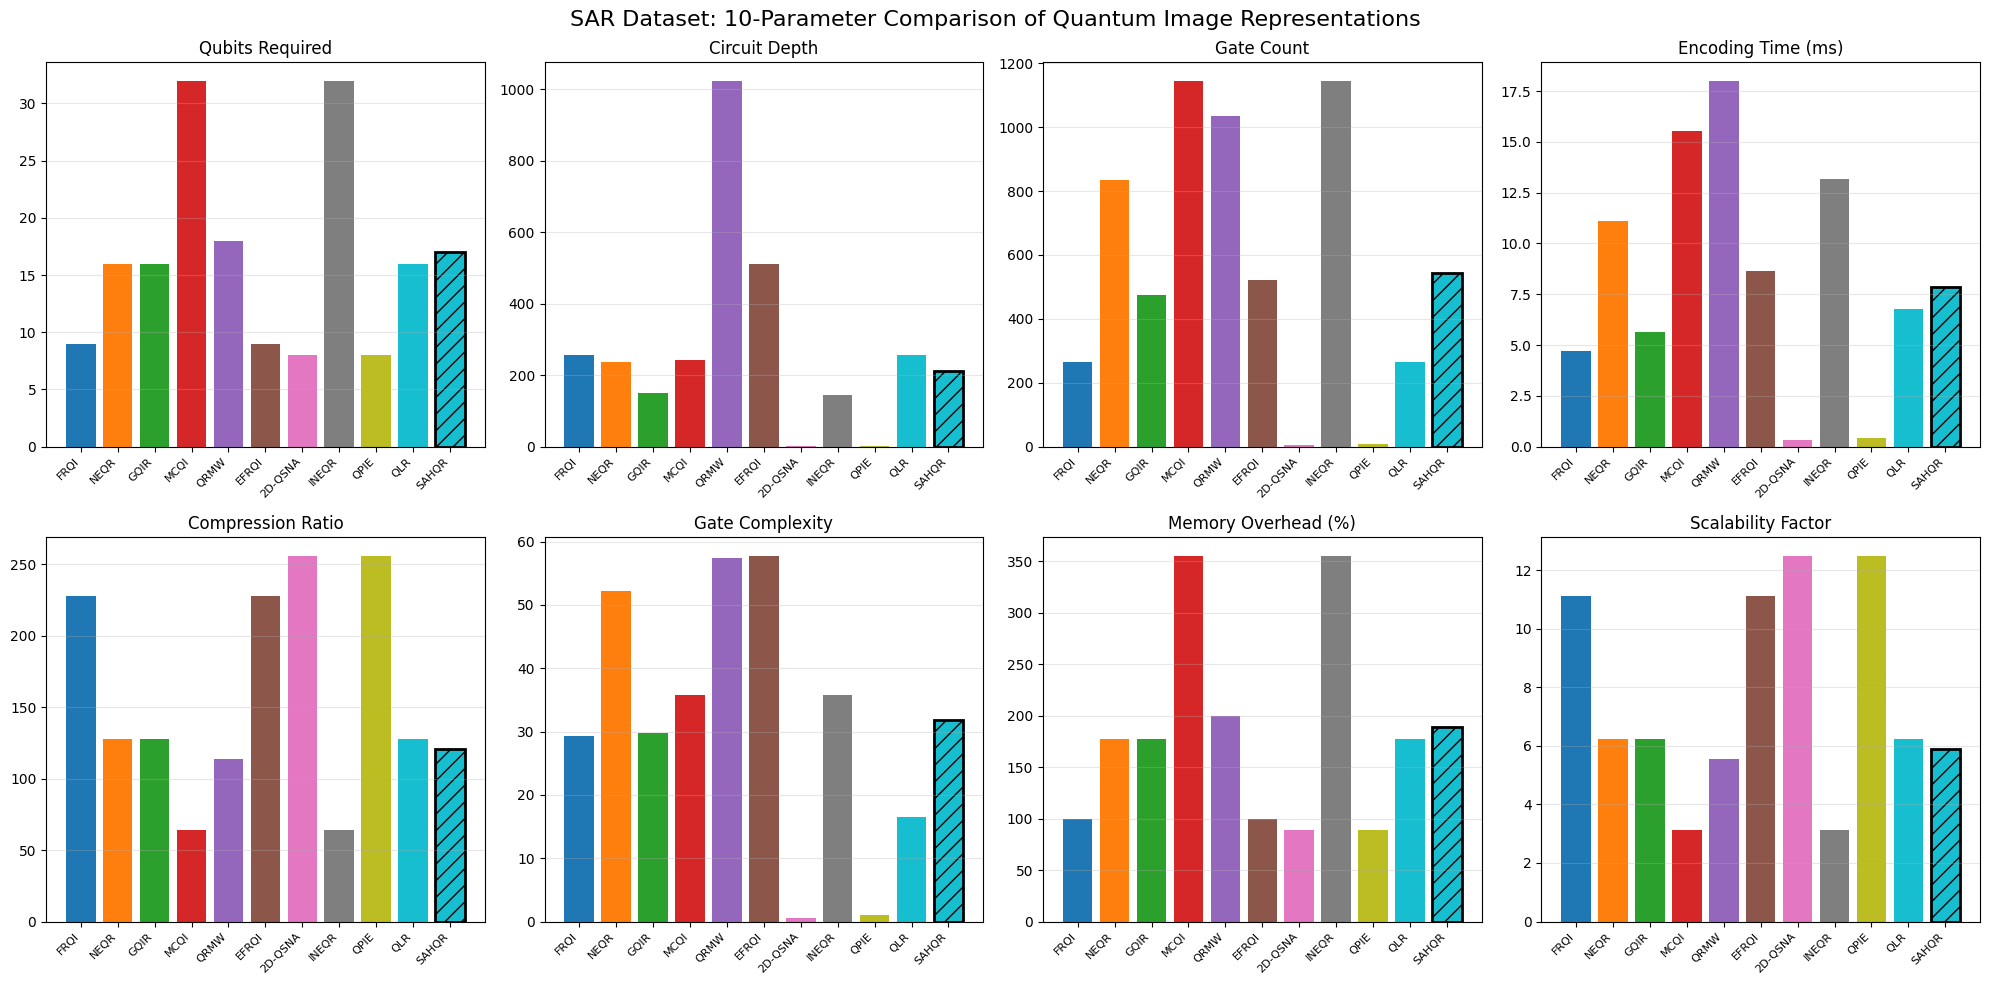

Figure saved to SAR_Results/figures/sar_10parameter_comparison.png


In [11]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('SAR Dataset: 10-Parameter Comparison of Quantum Image Representations', fontsize=16)

method_means = results_df.groupby('method').mean()
methods = method_order

# Color scheme
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
sahqr_idx = methods.index('SAHQR')

params = [
    ('qubits', 'Qubits Required'),
    ('depth', 'Circuit Depth'),
    ('gates', 'Gate Count'),
    ('encoding_time', 'Encoding Time (ms)'),
    ('compression_ratio', 'Compression Ratio'),
    ('gate_complexity', 'Gate Complexity'),
    ('memory_overhead', 'Memory Overhead (%)'),
    ('scalability', 'Scalability Factor')
]

for idx, (param, title) in enumerate(params):
    ax = axes.flat[idx]
    values = [method_means.loc[m, param] if m in method_means.index else 0 for m in methods]
    
    bars = ax.bar(range(len(methods)), values, color=colors)
    bars[sahqr_idx].set_hatch('//')
    bars[sahqr_idx].set_edgecolor('black')
    bars[sahqr_idx].set_linewidth(2)
    
    ax.set_xticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/figures/sar_10parameter_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved to {OUTPUT_DIR}/figures/sar_10parameter_comparison.png")

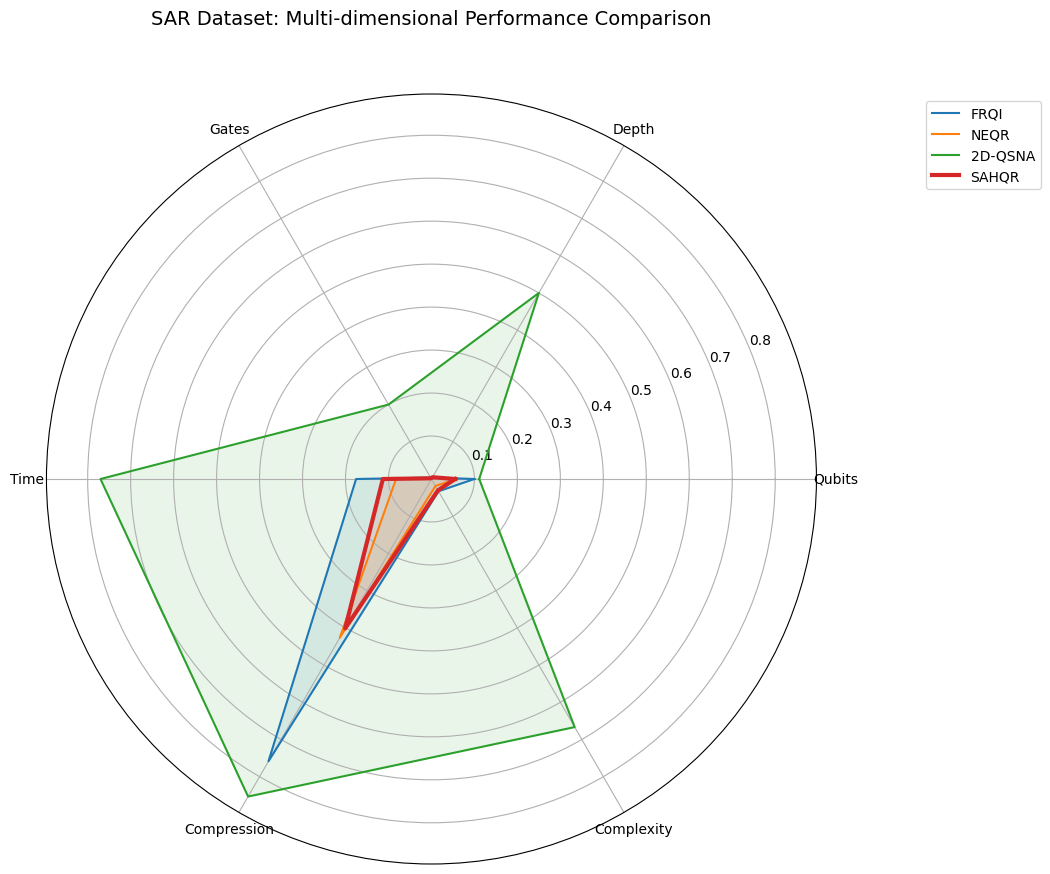

In [12]:
# Radar chart comparison
def create_radar_chart(data, methods, title, filename):
    categories = ['Qubits', 'Depth', 'Gates', 'Time', 'Compression', 'Complexity']
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    for method in methods:
        if method in data.index:
            values = [
                1 / (data.loc[method, 'qubits'] + 1),
                1 / (data.loc[method, 'depth'] + 1),
                1 / (data.loc[method, 'gates'] + 1),
                1 / (data.loc[method, 'encoding_time'] + 1),
                data.loc[method, 'compression_ratio'] / 300,
                1 / (data.loc[method, 'gate_complexity'] + 1)
            ]
            values = [min(v, 1) for v in values]
            values += values[:1]
            
            linewidth = 3 if method == 'SAHQR' else 1.5
            ax.plot(angles, values, linewidth=linewidth, label=method)
            ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_title(title, size=14, y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

create_radar_chart(
    method_means,
    ['FRQI', 'NEQR', '2D-QSNA', 'SAHQR'],
    'SAR Dataset: Multi-dimensional Performance Comparison',
    f'{OUTPUT_DIR}/figures/sar_radar_comparison.png'
)

## 9. Statistical Significance Testing

In [13]:
# SAHQR vs other methods t-tests
print("\nStatistical Significance Tests (SAHQR vs Others)")
print("="*60)

sahqr_data = results_df[results_df['method'] == 'SAHQR']

significance_results = []
for method in METHODS.keys():
    if method != 'SAHQR':
        method_data = results_df[results_df['method'] == method]
        
        # t-test for gates
        t_stat, p_val = stats.ttest_ind(sahqr_data['gates'], method_data['gates'])
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
        
        significance_results.append({
            'Comparison': f'SAHQR vs {method}',
            't-statistic': round(t_stat, 2),
            'p-value': f'{p_val:.2e}',
            'Significance': sig
        })

sig_df = pd.DataFrame(significance_results)
print(sig_df.to_string(index=False))

sig_df.to_csv(f'{OUTPUT_DIR}/sar_significance_tests.csv', index=False)


Statistical Significance Tests (SAHQR vs Others)
      Comparison  t-statistic   p-value Significance
   SAHQR vs FRQI       122.11  0.00e+00          ***
   SAHQR vs NEQR       -73.57  0.00e+00          ***
   SAHQR vs GQIR        22.99 5.50e-110          ***
   SAHQR vs MCQI      -165.63  0.00e+00          ***
   SAHQR vs QRMW      -216.16  0.00e+00          ***
  SAHQR vs EFRQI         9.65  8.69e-22          ***
SAHQR vs 2D-QSNA       236.34  0.00e+00          ***
  SAHQR vs INEQR      -165.63  0.00e+00          ***
   SAHQR vs QPIE       234.58  0.00e+00          ***
    SAHQR vs QLR       122.11  0.00e+00          ***


## 10. Final Summary

In [14]:
print("\n" + "="*80)
print("SAR DATASET EVALUATION COMPLETE")
print("="*80)
print(f"\nDataset: ICEYE SAR Satellite Image")
print(f"Total tiles processed: {len(preprocessed_tiles)}")
print(f"Tile size: {TILE_SIZE}x{TILE_SIZE} → 16x16")
print(f"Methods evaluated: {len(METHODS)}")
print(f"Total evaluations: {len(results_df)}")
print(f"\nResults saved to: {OUTPUT_DIR}/")
print("\nKey files generated:")
print(f"  - {OUTPUT_DIR}/sar_evaluation_results.csv")
print(f"  - {OUTPUT_DIR}/sar_significance_tests.csv")
print(f"  - {OUTPUT_DIR}/figures/sar_10parameter_comparison.png")
print(f"  - {OUTPUT_DIR}/figures/sar_radar_comparison.png")
print(f"  - {OUTPUT_DIR}/figures/sample_sar_tiles.png")


SAR DATASET EVALUATION COMPLETE

Dataset: ICEYE SAR Satellite Image
Total tiles processed: 2000
Tile size: 256x256 → 16x16
Methods evaluated: 11
Total evaluations: 22000

Results saved to: SAR_Results/

Key files generated:
  - SAR_Results/sar_evaluation_results.csv
  - SAR_Results/sar_significance_tests.csv
  - SAR_Results/figures/sar_10parameter_comparison.png
  - SAR_Results/figures/sar_radar_comparison.png
  - SAR_Results/figures/sample_sar_tiles.png
